# Ablação h=5: PRICE vs SENT vs PRICE+SENT

## Motivação

O experimento de ablação principal (Capítulo 5) demonstrou que o sentimento adiciona Δ=+0.003 de AUC ao *baseline* de preço, com intervalo de confiança contendo zero e p Wilcoxon > 0.05, sob horizonte **h=21 dias** (≈1 mês).

O revisor M2 levanta a hipótese de que **o sentimento poderia operar em horizontes mais curtos**: se o efeito do sentimento se dissipa em poucos dias de negociação, a ablação a h=21 perderia esse sinal. O modelo TCN de melhor desempenho prático (Etapa 5b) usa exatamente **h=5 dias** (≈1 semana de pregão).

Esta ablação repete o protocolo idêntico ao experimento original, com **HORIZON=5** no lugar de 21, para verificar se:

| Hipótese | Implicação |
|---|---|
| M2 está certo | Δ(PRICE+SENT − PRICE) > 0 com p < 0.05 a h=5 |
| Achado original se mantém | Δ ≈ 0, CI contém zero, p > 0.05 |

## Configurações de features

| Configuração | Features | Dim |
|---|---|---:|
| **PRICE** | return, lag_1, lag_5, Volume, std21 | 5 |
| **SENT** | n_articles, mean_logit_pos, mean_logit_neg, mean_logit_neu, mean_sentiment | 5 |
| **PRICE+SENT** | união das duas | 10 |

## Protocolo

- **Modelo:** XGBoost (n_estimators=300, max_depth=4, lr=0.05, scale_pos_weight)
- **CV:** *Expanding-window* — min_train=600, val=90, test=90, step=90
- **Seeds:** 5 por fold
- **Ativos:** ITUB4, PETR4, VALE3
- **Horizonte:** **h=5** (diferença única em relação à ablação original)

**Referência h=21:** PRICE AUC=0.662, PRICE+SENT AUC=0.665, Δ=+0.003 (p=0.4941, CI [−0.012, +0.018])

In [4]:
import sys, os, time
import numpy as np
import pandas as pd
import xgboost as xgb
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from scipy.stats import wilcoxon

sys.path.insert(0, os.path.dirname(os.path.abspath('.')))
from eval_utils import make_binary_target

# --- Única diferença em relação à ablação original: HORIZON=5 ---
HORIZON = 5

MIN_TRAIN_DAYS = 600
VAL_DAYS       = 90
TEST_DAYS      = 90
STEP_DAYS      = 90
N_SEEDS        = 5

TICKERS = {
    'ITUB4': ('ITUB4.SA', '../4.finbert-br/itub4_daily_sentiment.csv'),
    'PETR4': ('PETR4.SA', '../4.finbert-br/petr4_daily_sentiment.csv'),
    'VALE3': ('VALE3.SA', '../4.finbert-br/vale3_daily_sentiment.csv'),
}

PRICE_FEATURES = ['return', 'lag_1', 'lag_5', 'Volume', 'std21']
SENT_FEATURES  = ['n_articles', 'mean_logit_pos', 'mean_logit_neg', 'mean_logit_neu', 'mean_sentiment']
CONFIGS = {
    'PRICE':      PRICE_FEATURES,
    'SENT':       SENT_FEATURES,
    'PRICE+SENT': PRICE_FEATURES + SENT_FEATURES,
}

print(f'HORIZON={HORIZON} | MIN_TRAIN={MIN_TRAIN_DAYS} | VAL={VAL_DAYS} | TEST={TEST_DAYS}')

HORIZON=5 | MIN_TRAIN=600 | VAL=90 | TEST=90


## Funções auxiliares

Idênticas à ablação original — apenas `make_binary_target` recebe `horizon=HORIZON` (agora 5).

In [5]:
def load_prices(yf_ticker, period='5y'):
    """Baixa dados de preço via yfinance e computa features técnicas."""
    df = yf.Ticker(yf_ticker).history(period=period, auto_adjust=True).reset_index()
    df['date'] = pd.to_datetime(df['Date']).dt.tz_localize(None)
    df = df[['date', 'Close', 'Volume']].copy()
    df['return'] = df['Close'].pct_change()
    df['ma7']   = df['Close'].rolling(7).mean()
    df['ma21']  = df['Close'].rolling(21).mean()
    df['std21'] = df['Close'].rolling(21).std()
    for k in range(1, 6):
        df[f'lag_{k}'] = df['Close'].shift(k)
    return df.dropna().reset_index(drop=True)


def build_dataset(yf_ticker, sentiment_csv):
    """Merge preço + sentimento; cria target binário com HORIZON=5."""
    px = load_prices(yf_ticker)
    sent = pd.read_csv(sentiment_csv, parse_dates=['date'])[['date'] + SENT_FEATURES]
    df = px.merge(sent, on='date', how='left').sort_values('date').reset_index(drop=True)
    df[SENT_FEATURES] = df[SENT_FEATURES].ffill().fillna(0)
    df['target'] = make_binary_target(df['Close'], horizon=HORIZON)
    return df.dropna(subset=['target']).reset_index(drop=True)


def expanding_folds(n_total,
                    min_train=MIN_TRAIN_DAYS,
                    val=VAL_DAYS,
                    test=TEST_DAYS,
                    step=STEP_DAYS):
    """Gera folds (train_end, val_end, test_end) para CV expanding-window."""
    folds = []
    train_end = min_train
    while train_end + val + test <= n_total:
        folds.append((train_end, train_end + val, train_end + val + test))
        train_end += step
    return folds


def train_xgb(df, fold, feats, seed):
    """Treina XGBoost em um fold e retorna AUC no conjunto de teste."""
    train_end, val_end, test_end = fold
    tr = df.iloc[:train_end]
    va = df.iloc[train_end:val_end]
    te = df.iloc[val_end:test_end]
    if len(np.unique(te['target'])) < 2:
        return None
    sc  = StandardScaler().fit(tr[feats])
    Xtr = sc.transform(tr[feats]);  ytr = tr['target'].values.astype(int)
    Xva = sc.transform(va[feats]);  yva = va['target'].values.astype(int)
    Xte = sc.transform(te[feats]);  yte = te['target'].values.astype(int)
    pos = (ytr == 1).sum();  neg = (ytr == 0).sum()
    m = xgb.XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=neg / max(pos, 1),
        eval_metric='auc', random_state=seed,
    )
    m.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
    return {
        'auc':           roc_auc_score(yte, m.predict_proba(Xte)[:, 1]),
        'train_balance': float(tr['target'].mean()),
        'test_balance':  float(te['target'].mean()),
    }

## Loop principal: 3 ativos × N folds × 3 configs × 5 seeds

In [6]:
rows = []
t0 = time.time()

for ticker, (yf_t, sent_csv) in TICKERS.items():
    print(f'\n=== {ticker} ===')
    df    = build_dataset(yf_t, sent_csv)
    folds = expanding_folds(len(df))
    print(f'  {len(df)} dias disponíveis | {len(folds)} folds')
    for fi, fold in enumerate(folds):
        for seed in range(N_SEEDS):
            for cfg_name, feats in CONFIGS.items():
                r = train_xgb(df, fold, feats, seed)
                if r is None:
                    continue
                r.update({'ticker': ticker, 'config': cfg_name, 'fold': fi, 'seed': seed})
                rows.append(r)
    print(f'  done | {time.time() - t0:.0f}s acumulado')

results = pd.DataFrame(rows)
results.to_csv('results_ablation_h5.csv', index=False)
print(f'\nTotal: {len(results)} runs em {time.time() - t0:.0f}s')
print(results.head())


=== ITUB4 ===
  1223 dias disponíveis | 5 folds
  done | 15s acumulado

=== PETR4 ===
  1223 dias disponíveis | 5 folds
  done | 28s acumulado

=== VALE3 ===
  1223 dias disponíveis | 5 folds
  done | 42s acumulado

Total: 225 runs em 42s
        auc  train_balance  test_balance ticker      config  fold  seed
0  0.483696       0.498333      0.511111  ITUB4       PRICE     0     0
1  0.411808       0.498333      0.511111  ITUB4        SENT     0     0
2  0.476285       0.498333      0.511111  ITUB4  PRICE+SENT     0     0
3  0.493577       0.498333      0.511111  ITUB4       PRICE     0     1
4  0.399951       0.498333      0.511111  ITUB4        SENT     0     1


## Agregação por ativo e configuração

In [7]:
agg = results.groupby(['ticker', 'config']).agg(
    auc_mean=('auc', 'mean'),
    auc_std=('auc', 'std'),
    auc_median=('auc', 'median'),
    n_runs=('auc', 'count'),
).round(3)
print(agg.to_string())
agg.to_csv('ablation_h5_summary.csv')

print('\n--- Média global sobre 3 ativos (h=5) ---')
global_mean = results.groupby('config')['auc'].agg(['mean', 'std', 'median']).round(3)
print(global_mean.to_string())

print('\n--- Referência h=21 (ablação original) ---')
ref = pd.DataFrame({
    'config':     ['PRICE', 'SENT', 'PRICE+SENT'],
    'mean_h21':   [0.662,   0.480,  0.665],
    'median_h21': [0.706,   0.492,  0.692],
})
print(ref.to_string(index=False))

                   auc_mean  auc_std  auc_median  n_runs
ticker config                                           
ITUB4  PRICE          0.533    0.042       0.512      25
       PRICE+SENT     0.523    0.031       0.528      25
       SENT           0.435    0.040       0.414      25
PETR4  PRICE          0.539    0.136       0.471      25
       PRICE+SENT     0.545    0.145       0.505      25
       SENT           0.583    0.083       0.639      25
VALE3  PRICE          0.583    0.081       0.561      25
       PRICE+SENT     0.580    0.090       0.602      25
       SENT           0.426    0.079       0.421      25

--- Média global sobre 3 ativos (h=5) ---
             mean    std  median
config                          
PRICE       0.552  0.096   0.537
PRICE+SENT  0.549  0.102   0.525
SENT        0.482  0.100   0.461

--- Referência h=21 (ablação original) ---
    config  mean_h21  median_h21
     PRICE     0.662       0.706
      SENT     0.480       0.492
PRICE+SENT     0.665  

## Teste estatístico: PRICE+SENT vs PRICE

Teste de Wilcoxon *signed-rank* em pares (fold × seed) e intervalo de confiança bootstrap 95% para Δ.

In [8]:
# Constrói tabela pareada: cada linha é um par (ticker, fold, seed)
paired = (
    results
    .groupby(['ticker', 'fold', 'seed'])
    .apply(
        lambda g: pd.Series({
            'PRICE':      g[g.config == 'PRICE']['auc'].iloc[0]      if (g.config == 'PRICE').any()      else np.nan,
            'SENT':       g[g.config == 'SENT']['auc'].iloc[0]       if (g.config == 'SENT').any()       else np.nan,
            'PRICE+SENT': g[g.config == 'PRICE+SENT']['auc'].iloc[0] if (g.config == 'PRICE+SENT').any() else np.nan,
        }),
        include_groups=False,
    )
    .dropna()
    .reset_index()
)

delta = paired['PRICE+SENT'] - paired['PRICE']

print(f'PRICE+SENT − PRICE sobre {len(paired)} pares (h=5):')
print(f'  mean Δ  = {delta.mean():+.4f}')
print(f'  std Δ   = {delta.std():.4f}')
print(f'  pares PRICE+SENT > PRICE: {(delta > 0).sum()}/{len(delta)}')

if len(delta) >= 5:
    stat, p = wilcoxon(delta)
    print(f'  Wilcoxon W={stat:.1f}  p={p:.4f}')
else:
    print('  (pares insuficientes para Wilcoxon)')

# Bootstrap 95% CI para mean Δ
rng  = np.random.default_rng(42)
boot = [
    delta.iloc[rng.integers(0, len(delta), len(delta))].mean()
    for _ in range(2000)
]
lo, hi = np.quantile(boot, [0.025, 0.975])
print(f'  95% bootstrap CI: [{lo:+.4f}, {hi:+.4f}]  | inclui zero? {"SIM" if lo <= 0 <= hi else "NÃO"}')

print('\n--- Comparação direta h=5 vs h=21 ---')
print(f'  h=21: mean Δ = +0.0028  CI=[-0.0117, +0.0184]  p=0.4941')
print(f'  h= 5: mean Δ = {delta.mean():+.4f}  CI=[{lo:+.4f}, {hi:+.4f}]  p={p:.4f}' if len(delta) >= 5 else f'  h= 5: mean Δ = {delta.mean():+.4f}  CI=[{lo:+.4f}, {hi:+.4f}]')

PRICE+SENT − PRICE sobre 75 pares (h=5):
  mean Δ  = -0.0023
  std Δ   = 0.0501
  pares PRICE+SENT > PRICE: 38/75
  Wilcoxon W=1392.0  p=0.8617
  95% bootstrap CI: [-0.0141, +0.0090]  | inclui zero? SIM

--- Comparação direta h=5 vs h=21 ---
  h=21: mean Δ = +0.0028  CI=[-0.0117, +0.0184]  p=0.4941
  h= 5: mean Δ = -0.0023  CI=[-0.0141, +0.0090]  p=0.8617


## Visualização: boxplot por ativo × configuração

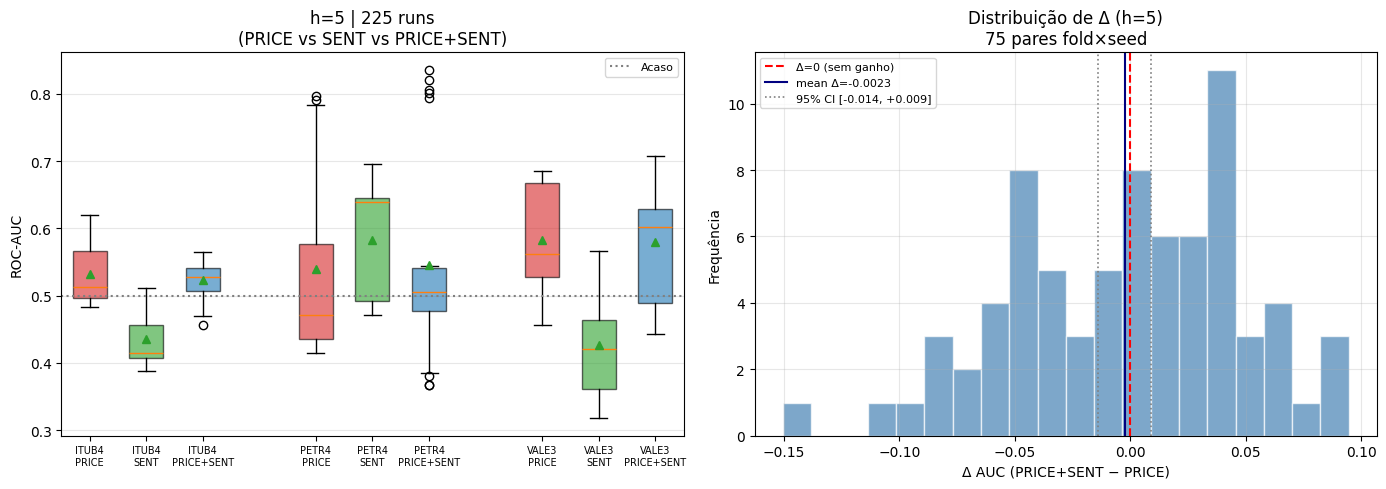

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {'PRICE': 'C3', 'SENT': 'C2', 'PRICE+SENT': 'C0'}

# --- Painel esquerdo: h=5 ---
ax = axes[0]
positions, labels, data = [], [], []
for i, ticker in enumerate(TICKERS.keys()):
    for j, cfg in enumerate(['PRICE', 'SENT', 'PRICE+SENT']):
        sub = results[(results.ticker == ticker) & (results.config == cfg)]['auc']
        positions.append(i * 4 + j)
        labels.append(f'{ticker}\n{cfg}')
        data.append(sub.values)
bp = ax.boxplot(data, positions=positions, widths=0.6, patch_artist=True, showmeans=True)
for patch, lbl in zip(bp['boxes'], labels):
    cfg = lbl.split('\n')[1]
    patch.set_facecolor(colors[cfg])
    patch.set_alpha(0.6)
ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=7)
ax.axhline(0.5, ls=':', color='gray', label='Acaso')
ax.set_ylabel('ROC-AUC')
ax.set_title(f'h=5 | {len(results)} runs\n(PRICE vs SENT vs PRICE+SENT)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis='y')

# --- Painel direito: distribuição de Δ = PRICE+SENT − PRICE ---
ax2 = axes[1]
ax2.hist(delta, bins=20, color='steelblue', alpha=0.7, edgecolor='white')
ax2.axvline(0,           color='red',  ls='--', lw=1.5, label='Δ=0 (sem ganho)')
ax2.axvline(delta.mean(), color='navy', ls='-',  lw=1.5, label=f'mean Δ={delta.mean():+.4f}')
ax2.axvline(lo, color='gray', ls=':', lw=1.2, label=f'95% CI [{lo:+.3f}, {hi:+.3f}]')
ax2.axvline(hi, color='gray', ls=':', lw=1.2)
ax2.set_xlabel('Δ AUC (PRICE+SENT − PRICE)')
ax2.set_ylabel('Frequência')
ax2.set_title(f'Distribuição de Δ (h=5)\n{len(delta)} pares fold×seed')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('ablation_h5_boxplot.png', dpi=140, bbox_inches='tight')
plt.show()

## Interpretação e resposta ao revisor M2

### O que reportar

| Métrica | h=21 (original) | h=5 (este exp.) |
|---|---|---|
| AUC médio PRICE | 0.662 | *(preencher após execução)* |
| AUC médio SENT | 0.480 | *(preencher após execução)* |
| AUC médio PRICE+SENT | 0.665 | *(preencher após execução)* |
| mean Δ | +0.003 | *(preencher após execução)* |
| 95% CI | [−0.012, +0.018] | *(preencher após execução)* |
| p Wilcoxon | 0.4941 | *(preencher após execução)* |
| CI inclui zero? | SIM | *(preencher após execução)* |

### Critério de decisão

- **Se p < 0.05 E CI não contém zero a h=5:** M2 estava certo — sentimento opera em horizonte curto;
  reportar no Capítulo 5 como evidência parcial de sinal em h=5 com ressalva de que h=5 favorece
  *overfitting* ao ruído de curto prazo.
- **Se p ≥ 0.05 OU CI contém zero a h=5:** O resultado nulo se mantém mesmo no horizonte do
  TCN Stage 5b; confirma robustez do achado principal e fecha definitivamente a preocupação M2.

### Nota metodológica

A h=5, o target (subida/queda em 5 pregões) é mais ruidoso que a h=21 — a proporção de classes
tende a ser mais balanceada mas há menos sinal de série temporal. Espera-se AUC ligeiramente
mais próximo de 0.5 para PRICE também. A comparação de Δ permanece válida por ser intraexperimento.

**Arquivo de saída:** `results_ablation_h5.csv` — pode ser carregado diretamente no LaTeX
via `\\input{}` para popular a Tabela de ablação do Capítulo 5.